# Iris Classification

**Getting the Dataset**

In [52]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

iris = load_iris()
scaler = MinMaxScaler()
features = iris['data']
labels = iris['target']
class_names = iris['target_names']
feature_names = iris['feature_names']

print(f"Features: {feature_names}, Classes: {class_names}")

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'], Classes: ['setosa' 'versicolor' 'virginica']


**Visualise the Data**

In [53]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame(features,columns=feature_names).join(pd.DataFrame(labels,columns=['Label']))

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


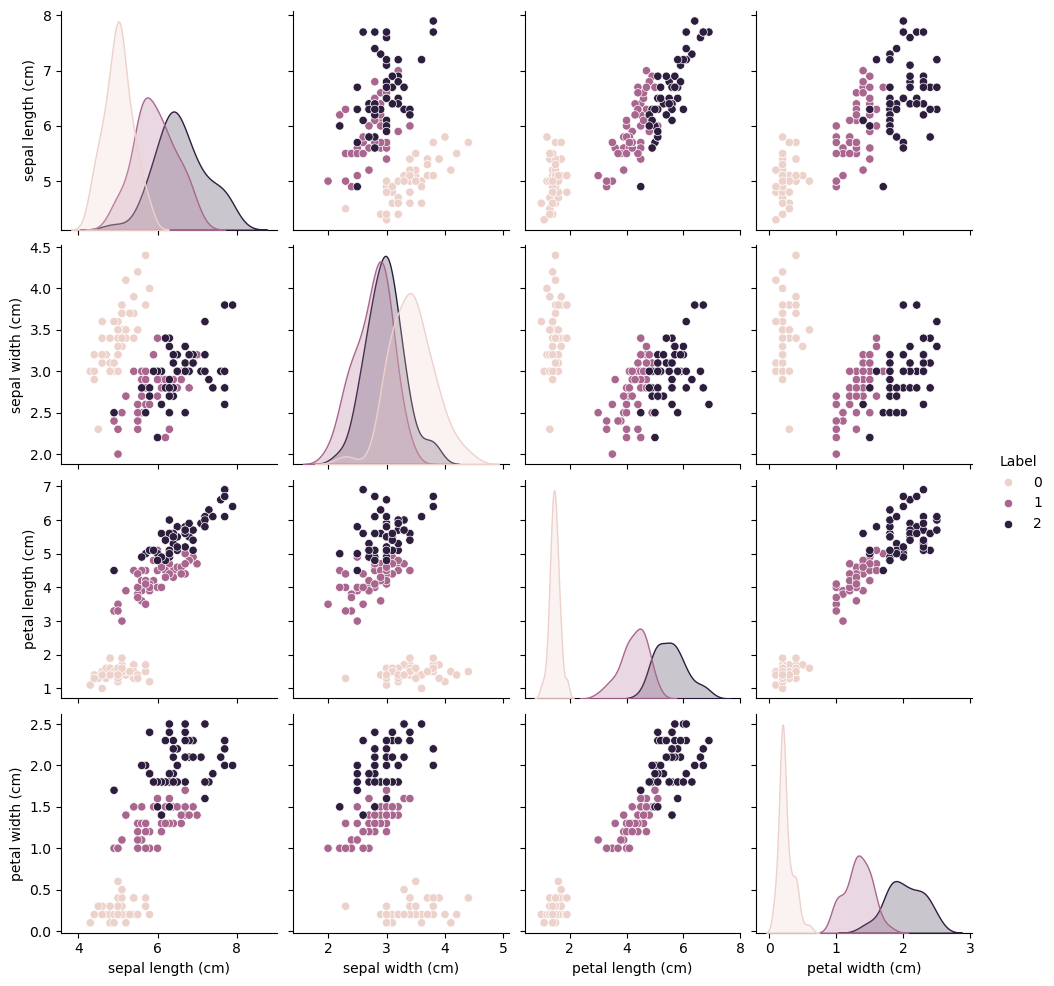

In [54]:

sns.pairplot(df,hue='Label')

**Normalise and Encode the Data**

In [55]:
# Normalise inputs in range [0,1]
features_normalised = scaler.fit_transform(features)
# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)
labels_encoded = encoder.fit_transform(labels.reshape(-1,1))

**Split the Data into Train and Test**

In [56]:
X_train, X_temp, y_train, y_temp = train_test_split(features_normalised, labels_encoded, test_size=0.2, random_state=42) # train (80%), temp (20%)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42) # valid (50%), test (50%)

**Define and Train Neural Network**

In [57]:
# Define the network
class MyNet(torch.nn.Module):
  def __init__(self,hidden_size=10,func=torch.nn.Sigmoid()):
    super().__init__()
    self.fc1 = torch.nn.Linear(4,hidden_size)
    self.func = func
    self.fc2 = torch.nn.Linear(hidden_size,3)

  def forward(self,x):
    x = self.fc1(x)
    x = self.func(x)
    x = self.fc2(x)
    return x
  
net = MyNet(func=torch.nn.ReLU())

In [58]:
# Train the network

train_losses = []
train_accs = []
val_losses = []
val_accs = []

dataset = torch.utils.data.TensorDataset(torch.tensor(X_train,dtype=torch.float32),torch.tensor(y_train,dtype=torch.float32))
dataloader = torch.utils.data.DataLoader(dataset,batch_size=16)
list(dataloader)[0]

val_x = torch.tensor(X_valid, dtype=torch.float32)
val_lab = torch.tensor(y_valid, dtype=torch.float32)

def train(net, dataloader, val_x, val_lab, epochs=10, lr=0.05):
  optim = torch.optim.Adam(net.parameters(), lr=lr)
  for ep in range(epochs):
      net.train()
      running_loss = 0.0
      running_correct = 0
      total = 0

      for x, y in dataloader:
        z = net(x)
        train_loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

        optim.zero_grad()
        train_loss.backward()
        optim.step()

        running_loss += train_loss.item() * x.size(0)
        pred = (torch.sigmoid(z) > 0.5).float()
        running_correct += (pred == y).all(dim=1).sum().item()
        total += x.size(0)

      epoch_train_loss = running_loss / total
      epoch_train_acc = running_correct / total

      # validation
      net.eval()
      with torch.no_grad():
        val_out = net(val_x)
        val_loss = torch.nn.functional.binary_cross_entropy_with_logits(val_out, val_lab)
        val_acc = ((torch.sigmoid(val_out) > 0.5).float() == val_lab).all(dim=1).float().mean().item()

      train_losses.append(epoch_train_loss)
      train_accs.append(epoch_train_acc)
      val_losses.append(val_loss.item())
      val_accs.append(val_acc)

train(net, dataloader, val_x, val_lab, lr=0.03)

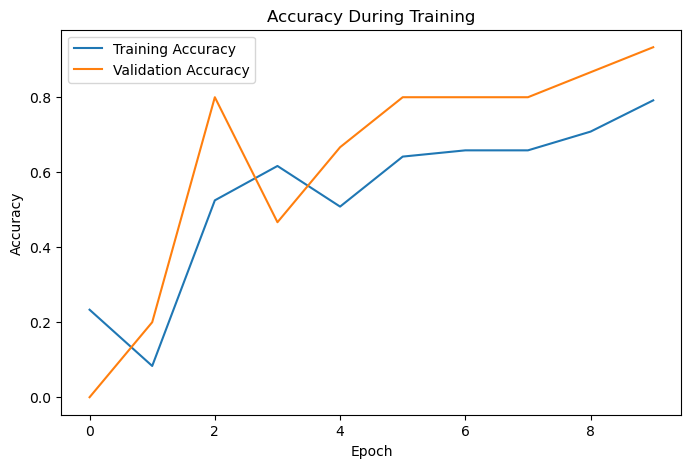

In [59]:
# Visualise train/validation accuracy graph
def acc_graph(heading="Accuracy During Training"):
    plt.figure(figsize=(8,5))

    plt.plot(train_accs, label="Training Accuracy")
    plt.plot(val_accs, label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(heading)

    plt.legend()
    plt.show()

acc_graph()
train_losses, train_accs, val_losses, val_accs = [], [], [], [] # reset

**Experiment**

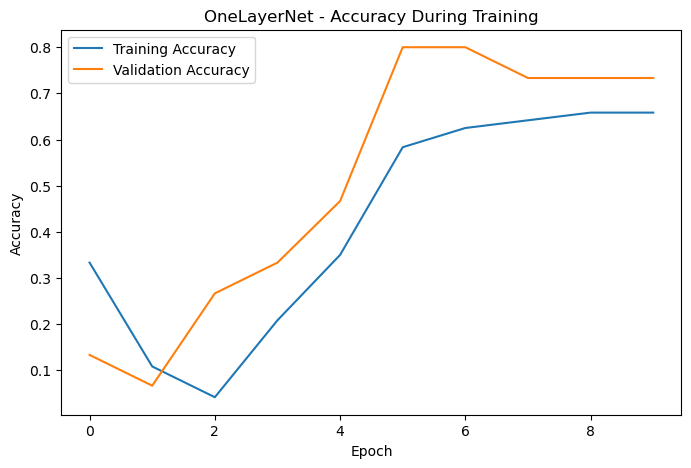

In [60]:
# One-layer network with 3 neurons (equal to the number of classes)
class OneLayerNet(torch.nn.Module):
    def __init__(self):
      super().__init__()
      self.fc = torch.nn.Linear(4,3)  
    def forward(self,x):
      return self.fc(x)
    
net = OneLayerNet()
train(net, dataloader, val_x, val_lab, lr=0.03)

acc_graph("OneLayerNet - Accuracy During Training")
train_losses, train_accs, val_losses, val_accs = [], [], [], [] # reset

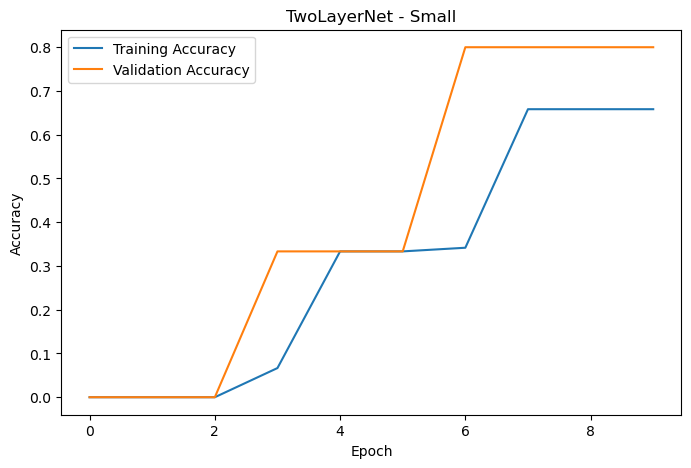

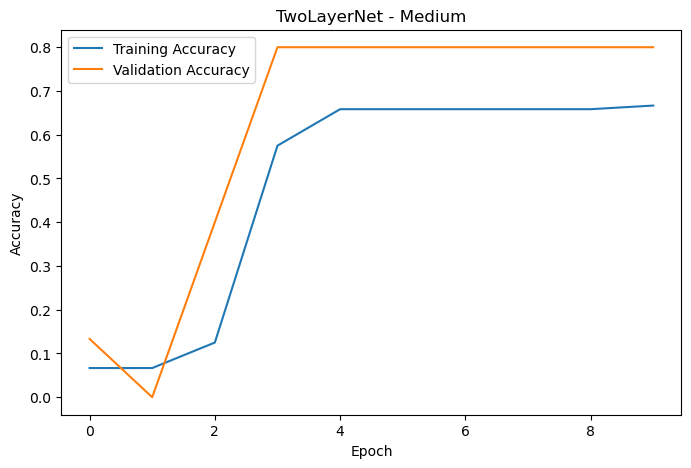

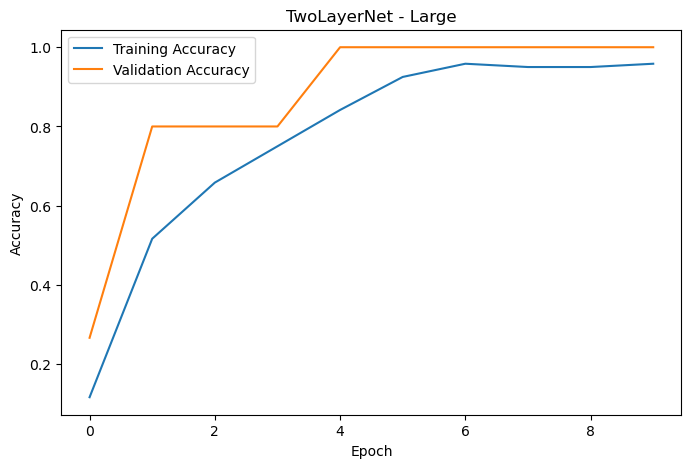

In [61]:
# Two-layer network with small/medium/large hidden layer

class TwoLayerNetSmall(torch.nn.Module): # 5 hidden neurons
    def __init__(self):
        super().__init__()
        self.fc1 = torch.nn.Linear(4, 5)
        self.fc2 = torch.nn.Linear(5, 3)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
class TwoLayerNetMedium(torch.nn.Module): # 10 hidden neurons
    def __init__(self):
        super().__init__()
        self.fc1 = torch.nn.Linear(4, 10)
        self.fc2 = torch.nn.Linear(10, 3)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class TwoLayerNetLarge(torch.nn.Module): # 50 hidden nuerons
    def __init__(self):
        super().__init__()
        self.fc1 = torch.nn.Linear(4, 50)  # 4 inputs → 50 hidden
        self.fc2 = torch.nn.Linear(50, 3)  # 50 hidden → 3 outputs
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
# train and plot
train(TwoLayerNetSmall(), dataloader, val_x, val_lab, lr=0.03)
acc_graph("TwoLayerNet - Small")
train_losses, train_accs, val_losses, val_accs = [], [], [], [] # reset

train(TwoLayerNetMedium(), dataloader, val_x, val_lab, lr=0.03)
acc_graph("TwoLayerNet - Medium")
train_losses, train_accs, val_losses, val_accs = [], [], [], [] # reset

train(TwoLayerNetLarge(), dataloader, val_x, val_lab, lr=0.03)
acc_graph("TwoLayerNet - Large")
train_losses, train_accs, val_losses, val_accs = [], [], [], [] # reset

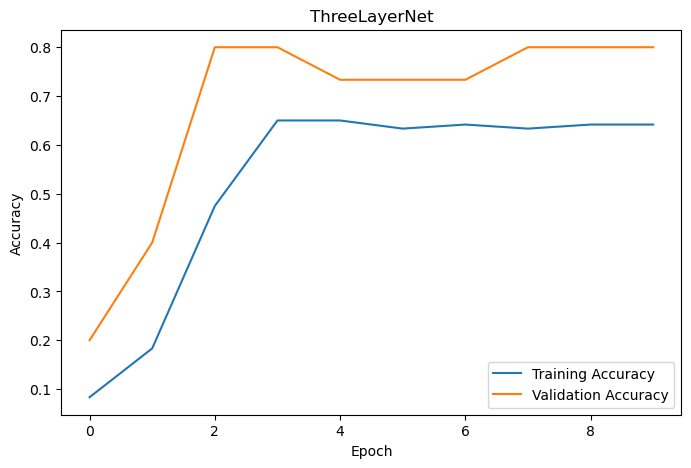

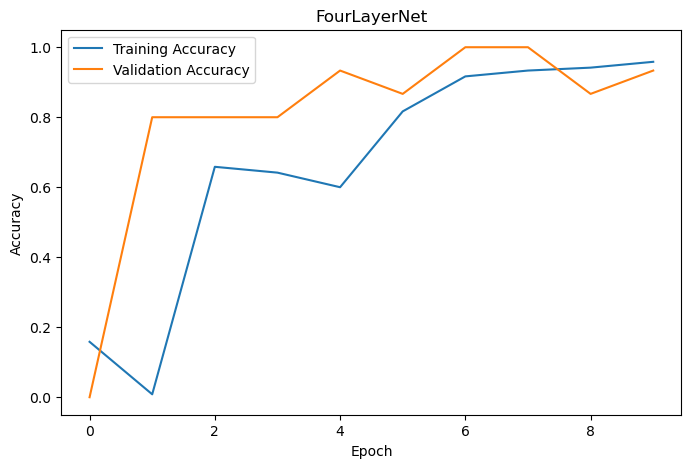

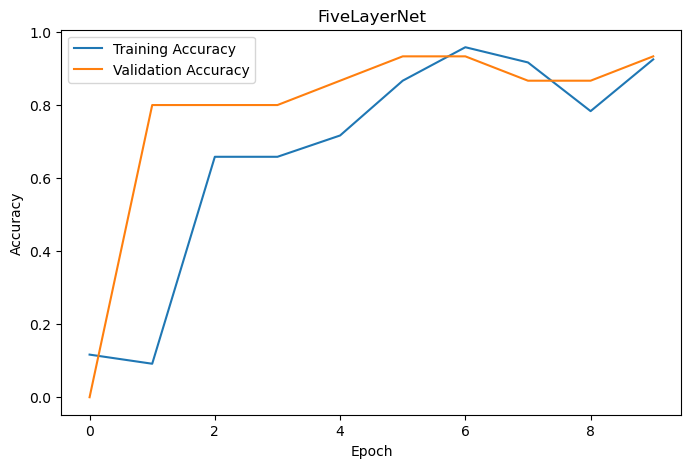

In [62]:
# Using more layers
class ThreeLayerNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = torch.nn.Linear(4, 10)
        self.fc2 = torch.nn.Linear(10, 8)
        self.fc3 = torch.nn.Linear(8, 3)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)
    
class FourLayerNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = torch.nn.Linear(4, 12)
        self.fc2 = torch.nn.Linear(12, 10)
        self.fc3 = torch.nn.Linear(10, 8)
        self.fc4 = torch.nn.Linear(8, 3)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        return self.fc4(x)

class FiveLayerNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = torch.nn.Linear(4, 15)
        self.fc2 = torch.nn.Linear(15, 12)
        self.fc3 = torch.nn.Linear(12, 10)
        self.fc4 = torch.nn.Linear(10, 8)
        self.fc5 = torch.nn.Linear(8, 3)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        return self.fc5(x)
    
# training and plot
train(ThreeLayerNet(), dataloader, val_x, val_lab, lr=0.03)
acc_graph("ThreeLayerNet")
train_losses, train_accs, val_losses, val_accs = [], [], [], [] # reset

train(FourLayerNet(), dataloader, val_x, val_lab, lr=0.03)
acc_graph("FourLayerNet")
train_losses, train_accs, val_losses, val_accs = [], [], [], [] # reset

train(FiveLayerNet(), dataloader, val_x, val_lab, lr=0.03)
acc_graph("FiveLayerNet")
train_losses, train_accs, val_losses, val_accs = [], [], [], [] # reset

# Part 2: MNIST Training

In [63]:
# Load the dataset

# Using Python's urllib/gzip instead of wget/gzip shell commands,
# since wget is not available by default on Windows
import urllib.request
import gzip
import shutil

url = "https://raw.githubusercontent.com/microsoft/AI-For-Beginners/main/data/mnist.pkl.gz"

urllib.request.urlretrieve(url, "mnist.pkl.gz")

with gzip.open("mnist.pkl.gz", "rb") as f_in:
    with open("mnist.pkl", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

import pickle
with open('mnist.pkl','rb') as f:
    raw_data = pickle.load(f, encoding='latin1') # Added encoding='latin1' to fix a Python 2 vs Python 3 pickle compatibility issue

# The downloaded pickle file uses the (train, valid, test) tuple format,
# not the {'Train': {...}, 'Test': {...}} dict format this notebook expects.
# Manually reconstructing the expected dictionary structure here.
training_data, validation_data, test_data = raw_data

MNIST = {
    'Train': {
        'Features': training_data[0],
        'Labels': training_data[1]
    },
    'Test': {
        'Features': test_data[0],
        'Labels': test_data[1]
    }
}

labels = MNIST['Train']['Labels']
data = MNIST['Train']['Features']

**Normalise the Data**

In [64]:
normalised_data = scaler.fit_transform(data)

**Split the Data into Train and Test**

In [65]:
features_train, features_temp, labels_train, labels_temp = train_test_split(normalised_data,labels,test_size=0.2) # train (80%), temp (20%)
features_valid, features_test, labels_valid, labels_test = train_test_split(features_temp,labels_temp,test_size=0.5) # vaild (50%), test (50%)

**Define and Train Neural Network**

In [66]:
# Define the network
class MyNet(torch.nn.Module):
  def __init__(self,hidden_size=100,func=torch.nn.Sigmoid()):
    super().__init__()
    self.fc1 = torch.nn.Linear(784,hidden_size)
    self.func = func
    self.fc2 = torch.nn.Linear(hidden_size,10)

  def forward(self,x):
    x = self.fc1(x)
    x = self.func(x)
    x = self.fc2(x)
    return x
  
net = MyNet(func=torch.nn.ReLU())

In [67]:
# Train the network

train_losses = []
train_accs = []
val_losses = []
val_accs = []

dataset = torch.utils.data.TensorDataset(torch.tensor(features_train, dtype=torch.float32), torch.tensor(labels_train, dtype=torch.long))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=16)
list(dataloader)[0]

val_x = torch.tensor(features_valid, dtype=torch.float32)
val_lab = torch.tensor(labels_valid, dtype=torch.long)

def train(net, dataloader, val_x, val_lab, epochs=10, lr=0.05):
  optim = torch.optim.Adam(net.parameters(), lr=lr)
  for ep in range(epochs):
    net.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for x, y in dataloader:
      z = net(x)
      train_loss = torch.nn.functional.cross_entropy(z, y)

      optim.zero_grad()
      train_loss.backward()
      optim.step()

      running_loss += train_loss.item() * x.size(0)
      pred_train = torch.argmax(z, dim=1)
      running_correct += (pred_train == y).sum().item()
      total += x.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = running_correct / total

    net.eval()
    with torch.no_grad():
      val_out = net(val_x)
      val_loss = torch.nn.functional.cross_entropy(val_out, val_lab)
      pred_val = torch.argmax(val_out, dim=1)
      val_acc = (pred_val == val_lab).float().mean().item()

    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    val_losses.append(val_loss.item())
    val_accs.append(val_acc)

net = MyNet(func=torch.nn.ReLU())

train(net, dataloader, val_x, val_lab, lr=0.03)

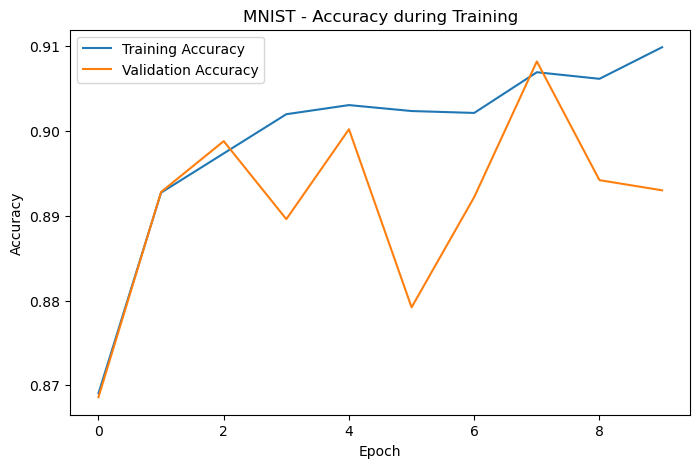

In [68]:
# Visualise train/validation accuracy graph
acc_graph("MNIST - Accuracy during Training")